In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D


In [2]:
file_path = r'G:\.shortcut-targets-by-id\1u93J-JGxtx7vOpkuufdsEGMvt3u8paey\divar_analysis\clustering_input_clean.parquet'

data = pd.read_parquet(file_path)
data.head()

,ad_id,city_slug,deal_type_cat,utm_zone,property_category_cat,price_position_z_raw,is_sale_raw,building_size_raw,rooms_count_raw,utm_easting_raw,utm_northing_raw,amenity_score_raw,price_position_z_scaled,is_sale_scaled,building_size_scaled,rooms_count_scaled,utm_easting_scaled,utm_northing_scaled,amenity_score_scaled
0,0,karaj,temporary_rent,39,villa,0.256750,0.0,292.5,3.0,4.942723e+05,3.963064e+06,0.0,0.288886,-1.218564,2.070845,1.452489,-0.250704,0.388086,-1.131432
1,1,tehran,sell,39,apartment,0.845426,1.0,60.0,1.0,5.399990e+05,3.958893e+06,1.0,0.960003,0.820638,-0.884402,-1.023646,-0.105017,0.373613,1.234447
2,2,tehran,rent,39,apartment,1.009912,0.0,132.0,3.0,5.337844e+05,3.951168e+06,1.0,1.147523,-1.218564,0.030771,1.452489,-0.124817,0.346808,1.234447
3,3,tehran,rent,39,office,1.840001,0.0,90.0,1.0,5.385443e+05,3.960860e+06,1.0,2.093860,-1.218564,-0.503080,-1.023646,-0.109652,0.380438,1.234447
4,4,mashhad,sell,39,apartment,0.529831,1.0,115.0,2.0,1.273229e+06,4.048566e+06,1.0,0.600210,0.820638,-0.185312,0.214421,2.231074,0.684778,1.234447


In [3]:
K = 10
SEED = 42
SAMPLE_N = 20000
N_RUNS = 3          

In [4]:
candidates = ['price_position_z', 'building_size', 'rooms_count',
              'utm_easting', 'utm_northing', 'amenity_score']

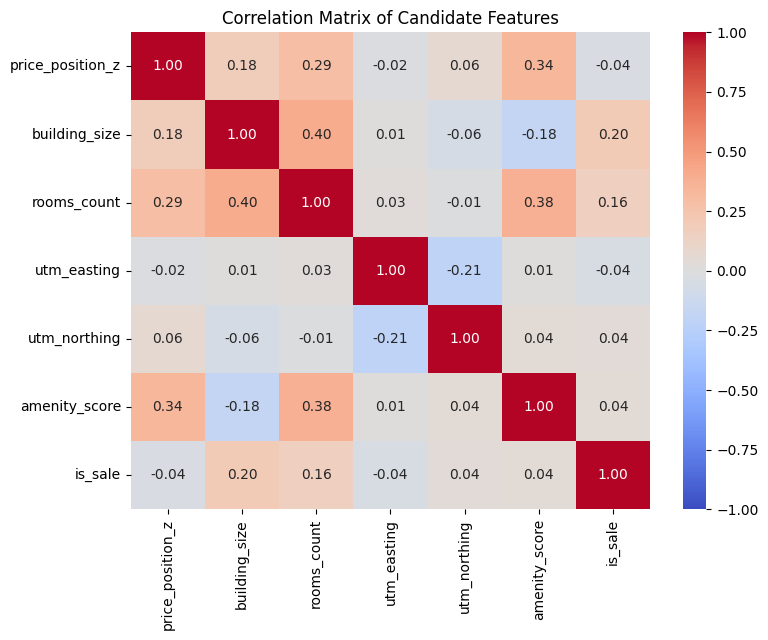

In [5]:
raw_map = {f + '_raw': f for f in candidates + ['is_sale']}
corr = data[list(raw_map)].rename(columns=raw_map).corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Candidate Features')
plt.tight_layout()
plt.show()


<div dir="rtl">
Featureها correlation خطی خیلی بالایی باهم ندارند، بنابراین از نظر همپوشانی خطی، حذف feature خاصی ضروری به نظر نمیاد. اما این هیت مپ به‌تنهایی نمیگه کدوم featureها برای K Means بهترینن.

</div>

In [6]:
frac = SAMPLE_N / len(data)
sample = data.groupby(['city_slug', 'is_sale_raw']).sample(frac=frac, random_state=SEED)

# چک منطقی که آیا سمپل نماینده خوبی هست یا نه:
print(f'Sample size: {len(sample):,}')
print(f"is_sale share -> full: {data['is_sale_raw'].mean():.3f} | sample: {sample['is_sale_raw'].mean():.3f}")
top = data['city_slug'].value_counts(normalize=True).head(5)
print(pd.DataFrame({'full': top, 'sample': sample['city_slug'].value_counts(normalize=True).reindex(top.index)}).round(3))

Sample size: 19,991
is_sale share -> full: 0.598 | sample: 0.598
            full  sample
city_slug               
tehran     0.191   0.191
mashhad    0.069   0.069
karaj      0.049   0.049
shiraz     0.037   0.037
isfahan    0.037   0.037


In [7]:
mi_feats = [f for f in candidates if f != 'price_position_z'] + ['is_sale']
discrete = [f in ('rooms_count', 'amenity_score', 'is_sale') for f in mi_feats]
mi = mutual_info_regression(sample[[f + '_scaled' for f in mi_feats]],
                            sample['price_position_z_scaled'],
                            discrete_features=discrete, random_state=SEED)
print('\nMutual information with price_position_z:')
print(pd.Series(mi, index=mi_feats).sort_values(ascending=False).round(4))



Mutual information with price_position_z:
is_sale          0.4725
building_size    0.2790
utm_easting      0.2549
utm_northing     0.2530
rooms_count      0.1471
amenity_score    0.1398
dtype: float64



<div dir="rtl">
از mutual information  برای دیدن وابستگی غیرخطی استفاده شد و اینکه یه ویژگی چقدر اطلاعات درباره قیمت بهمون میده. <br>
البته هیچ‌کدوم معیار انتخاب نبودن چون K-Means متغیر هدف نداره.
</div>

In [8]:
def sil(feats):
    X = sample[[f + '_scaled' for f in feats]].values
    scores = []
    for run in range(N_RUNS):
        labels = KMeans(n_clusters=K, n_init=10, random_state=SEED + run).fit_predict(X)
        scores.append(silhouette_score(X, labels))
    return np.mean(scores), np.std(scores)

feature_sets = {'base (6 features)': candidates}
#میخوایم ببینیم نبود هر کاندید چقدر تاثیر داره روی خوشه بندی
for f in candidates:
    feature_sets[f'without {f}'] = [x for x in candidates if x != f]
feature_sets['with is_sale'] = candidates + ['is_sale']

rows = {name: sil(feats) for name, feats in feature_sets.items()}
sil_table = (pd.DataFrame(rows, index=['silhouette_mean', 'silhouette_std']).T.sort_values('silhouette_mean', ascending=False))
#سطر و ستونو جابجا و مرتب کردیم :)
sil_table['n_features'] = [len(feature_sets[n]) for n in sil_table.index]
print('\nSilhouette comparison (same sample, same K):')
print(sil_table.round(4))



Silhouette comparison (same sample, same K):
                          silhouette_mean  silhouette_std  n_features
without price_position_z           0.3109          0.0018           5
without utm_northing               0.2748          0.0049           5
without utm_easting                0.2726          0.0016           5
without building_size              0.2420          0.0019           5
without amenity_score              0.2418          0.0002           5
without rooms_count                0.2392          0.0042           5
base (6 features)                  0.2324          0.0004           6
with is_sale                       0.2117          0.0014           7


<div dir="rtl">
مجموعه‌ی ویژگی‌ها روی یک سمپل طبقه‌ای ثابت (۲۰ هزار آگهی، بر اساس شهر و نوع معامله) با silhouette مقایسه شد.
</div>

In [9]:
FINAL_FEATURES = candidates
FINAL_FEATURES

['price_position_z',
 'building_size',
 'rooms_count',
 'utm_easting',
 'utm_northing',
 'amenity_score']

In [10]:
X_full = data[[f + '_scaled' for f in FINAL_FEATURES]].values
km = KMeans(n_clusters=K, n_init=10, random_state=SEED)
data['cluster'] = km.fit_predict(X_full)
centers_scaled = km.cluster_centers_

In [11]:
raw_cols = [f + '_raw' for f in FINAL_FEATURES]
mu = data[raw_cols].mean().values
sd = data[raw_cols].std(ddof=0).values
#تست چک: خودش دیتای خام رو نرمالایز میکنه، چک میکنه با ورودی خودمون و تا 0.001 اجازه اختلاف بهش میده. اگه برابر نبود، اون پیامو چاپ میکنه.
assert np.allclose((data[raw_cols].values - mu) / sd, X_full, atol=1e-3),'scaled columns do not match raw columns; use the saved scaler instead'

centers_raw = pd.DataFrame(centers_scaled * sd + mu, columns=FINAL_FEATURES)
centers_raw['cluster'] = range(K)
centers_raw['size'] = data['cluster'].value_counts().sort_index().values
print('\nCluster centers (real units):')
print(centers_raw.round(2).to_string(index=False))



Cluster centers (real units):
 price_position_z  building_size  rooms_count  utm_easting  utm_northing  amenity_score  cluster   size
             0.19          90.18         1.82    472256.24    3964271.64           1.00        0 176536
            -0.52         156.45         1.71    954686.13    3256277.22           0.14        1  67902
             1.11         270.69         1.78    510510.21    3890070.09           0.12        2  54689
            -0.16         100.28         2.08    432567.24    3967568.39           0.31        3 170939
            -0.66          85.54         1.19   1219594.53    4037563.55           0.15        4  44959
            -0.34          58.78         0.69    430874.23    3903468.66           0.17        5 164025
             0.12         121.42         2.23    582605.42    3370493.79           0.79        6  89847
             0.22         134.85         2.38   1242445.79    4039545.36           0.81        7  47802
            -0.87         261.96 

In [12]:
print('\nSale share inside each cluster:')
print(data.groupby('cluster')['is_sale_raw'].mean().round(2))


Sale share inside each cluster:
cluster
0    0.64
1    0.56
2    0.74
3    0.58
4    0.44
5    0.42
6    0.59
7    0.60
8    0.88
9    0.63
Name: is_sale_raw, dtype: float64


In [13]:
cat_ct = pd.crosstab(data['cluster'], data['property_category_cat'], normalize='index')
city_ct = pd.crosstab(data['cluster'], data['city_slug'], normalize='index')

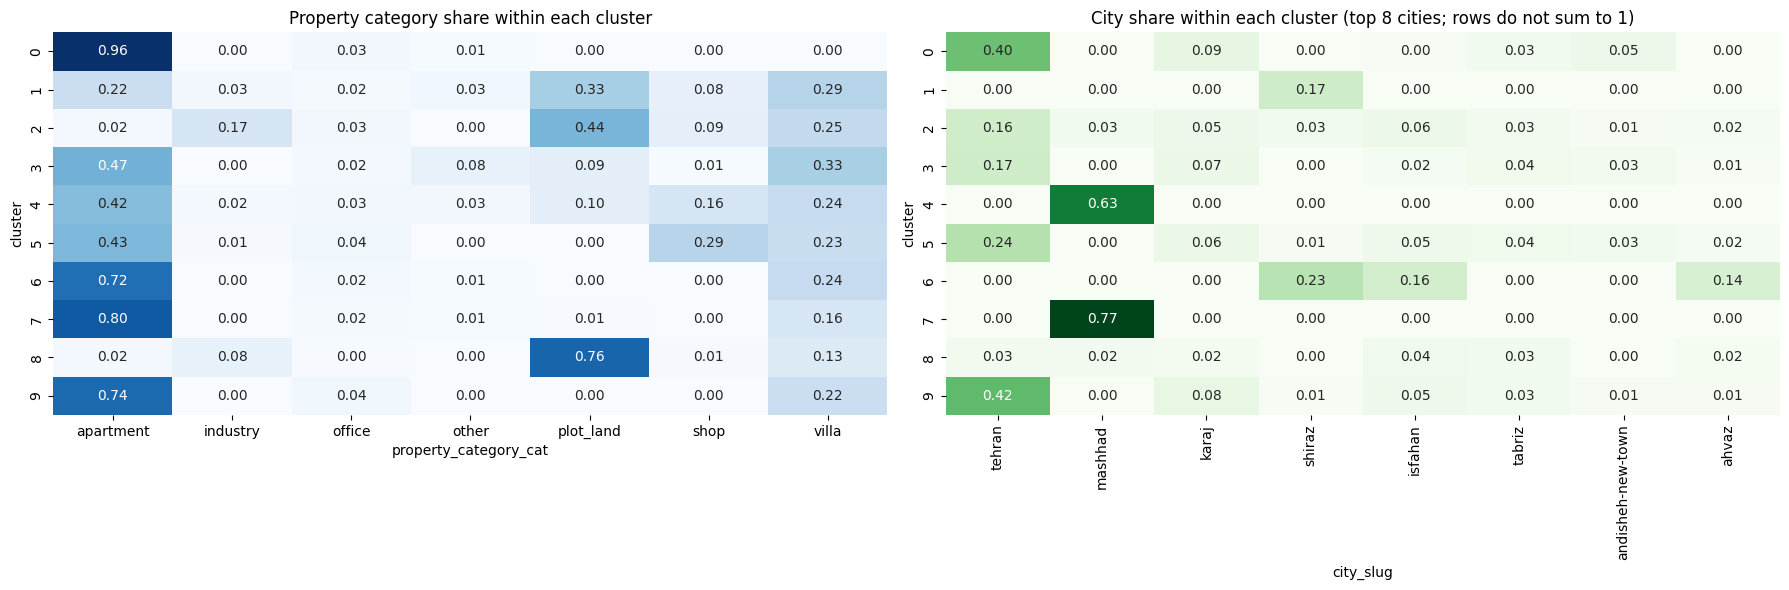

In [14]:
top_cities = data['city_slug'].value_counts().head(8).index
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(cat_ct, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Property category share within each cluster')
sns.heatmap(city_ct[top_cities], annot=True, fmt='.2f', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('City share within each cluster (top 8 cities; rows do not sum to 1)')
plt.tight_layout()
plt.show()

In [15]:
summary = centers_raw.copy()
summary['sale_share'] = data.groupby('cluster')['is_sale_raw'].mean().round(2).values
summary['top_category'] = cat_ct.idxmax(axis=1).values
summary['top_cat_share'] = cat_ct.max(axis=1).round(2).values
summary['top_city'] = city_ct.idxmax(axis=1).values
summary['top_city_share'] = city_ct.max(axis=1).round(2).values
print(summary.round(2).to_string(index=False))

 price_position_z  building_size  rooms_count  utm_easting  utm_northing  amenity_score  cluster   size  sale_share top_category  top_cat_share top_city  top_city_share
             0.19          90.18         1.82    472256.24    3964271.64           1.00        0 176536        0.64    apartment           0.96   tehran            0.40
            -0.52         156.45         1.71    954686.13    3256277.22           0.14        1  67902        0.56    plot_land           0.33   shiraz            0.17
             1.11         270.69         1.78    510510.21    3890070.09           0.12        2  54689        0.74    plot_land           0.44   tehran            0.16
            -0.16         100.28         2.08    432567.24    3967568.39           0.31        3 170939        0.58    apartment           0.47   tehran            0.17
            -0.66          85.54         1.19   1219594.53    4037563.55           0.15        4  44959        0.44    apartment           0.42  mashhad   

<div dir="rtl">

## نمایش نتایج K-Means (k=10) روی نقشهٔ UTM و قیمت

</div>

<div dir="rtl">
خوشه‌بندی روی کل داده (حدود ۱ میلیون آگهی) و روی ستون‌های _scaled انجام شد؛ برای رسم، چون ۱ میلیون نقطه روی هم می‌افتند و نمودار ناخوانا می‌شود، فقط از هر خوشه به نسبت اندازه‌اش یک نمونه (۶۰ هزارتایی) رسم می‌شود. مراکز خوشه‌ها همان مراکز مدل روی کل داده‌اند.
</div>

<div dir="rtl">
مراکز خوشه‌ها در فضای استانداردشده هستند؛ برای گزارش، با تبدیل معکوس (center × sd + mean) به واحد واقعی برگشتند (جدول بالا) و در نمودارها همین مقادیر واقعی رسم شدن.

</div>

<div dir="rtl">
مختصات جغرافیایی از قبل به UTM تبدیل شده‌اند (utm_easting و utm_northing، متر). همه در zone 39 هستند؛ به همین دلیل easting شهرهای شرقی مثل مشهد بزرگ‌تر از ۱ میلیون متر شده.

</div>

<div dir="rtl">
«قیمت» در این داده price_position_z است، یعنی موقعیت قیمتی آگهی نسبت به بقیه (z-score، بدون واحد). عدد بالاتر یعنی گران‌تر از معمول.
</div>

In [16]:
print(data['utm_zone'].value_counts())

utm_zone
39    999998
Name: count, dtype: int64


In [18]:
PLOT_N = 60000
plot_df = data.groupby('cluster', group_keys=False).sample(frac=PLOT_N / len(data), random_state=SEED)

colors = plt.get_cmap('tab10').colors
sizes = data['cluster'].value_counts().sort_index()

legend_handles = [Line2D([0], [0], marker='o', linestyle='', color=colors[c], markersize=9,
                         label=f'Cluster {c} (n={sizes[c]:,})') for c in range(K)]
legend_handles.append(Line2D([0], [0], marker='X', linestyle='', markerfacecolor='white',
                             markeredgecolor='black', markeredgewidth=1.5, markersize=13,
                             label='Cluster center (mean, not a real listing)'))

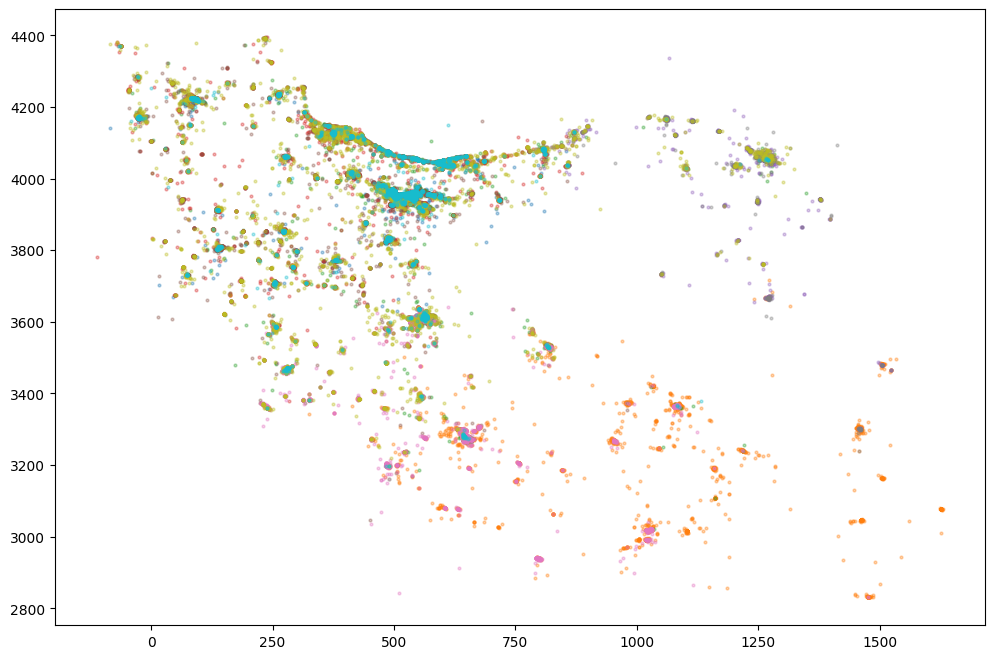

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))

for c in range(K):
    pts = plot_df[plot_df['cluster'] == c]
    ax.scatter(pts['utm_easting_raw'] / 1000, pts['utm_northing_raw'] / 1000,
               s=4, alpha=0.35, color=colors[c], rasterized=True)

<div dir="rtl">
صرفا جهت نمایش پراکندگی :)
</div>

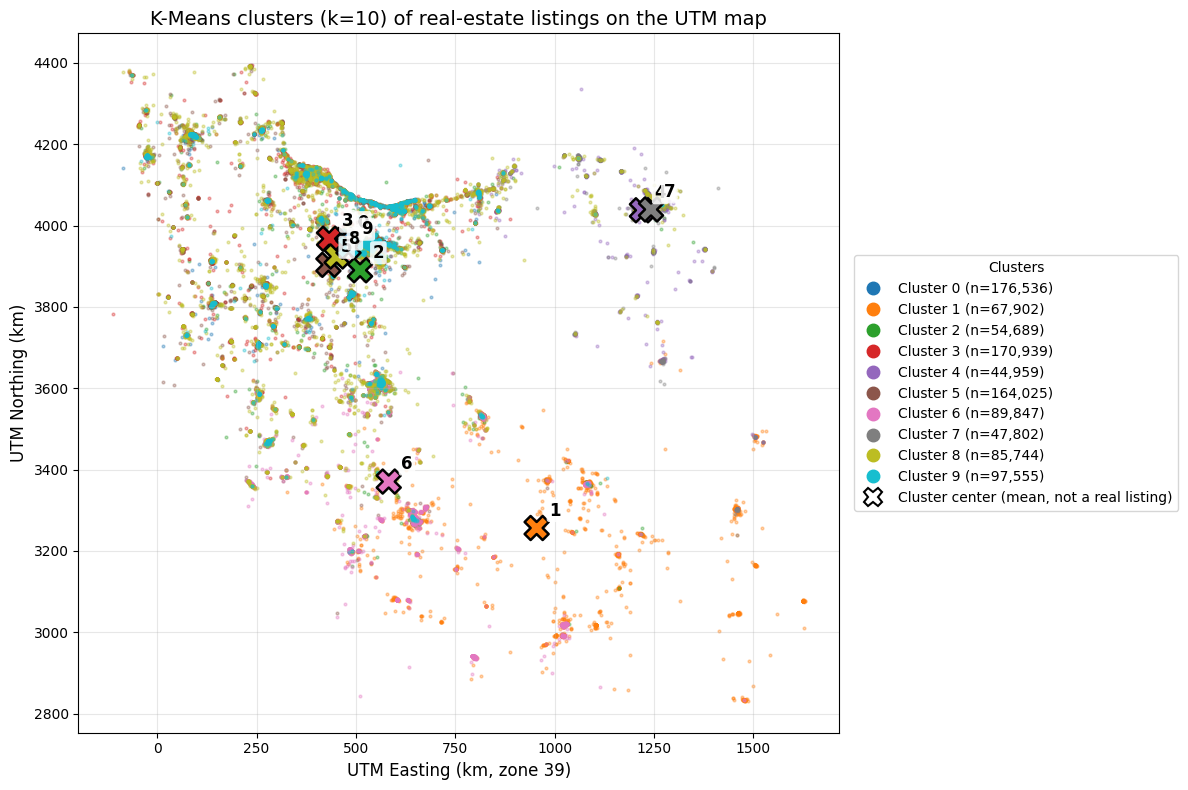

In [30]:

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(K):
    pts = plot_df[plot_df['cluster'] == c]
    ax.scatter(pts['utm_easting_raw'] / 1000, pts['utm_northing_raw'] / 1000,
               s=4, alpha=0.35, color=colors[c], rasterized=True)

ax.scatter(centers_raw['utm_easting'] / 1000, centers_raw['utm_northing'] / 1000,
           marker='X', s=300, c=[colors[c] for c in range(K)],
           edgecolors='black', linewidths=1.8, zorder=5)
for c in range(K):
    ax.annotate(str(c), (centers_raw.loc[c, 'utm_easting'] / 1000, centers_raw.loc[c, 'utm_northing'] / 1000),
                xytext=(9, 9), textcoords='offset points', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85), zorder=6)

ax.set_xlabel('UTM Easting (km, zone 39)', fontsize=12)
ax.set_ylabel('UTM Northing (km)', fontsize=12)
ax.set_title('K-Means clusters (k=10) of real-estate listings on the UTM map', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title='Clusters', frameon=True)
plt.tight_layout()
plt.show()

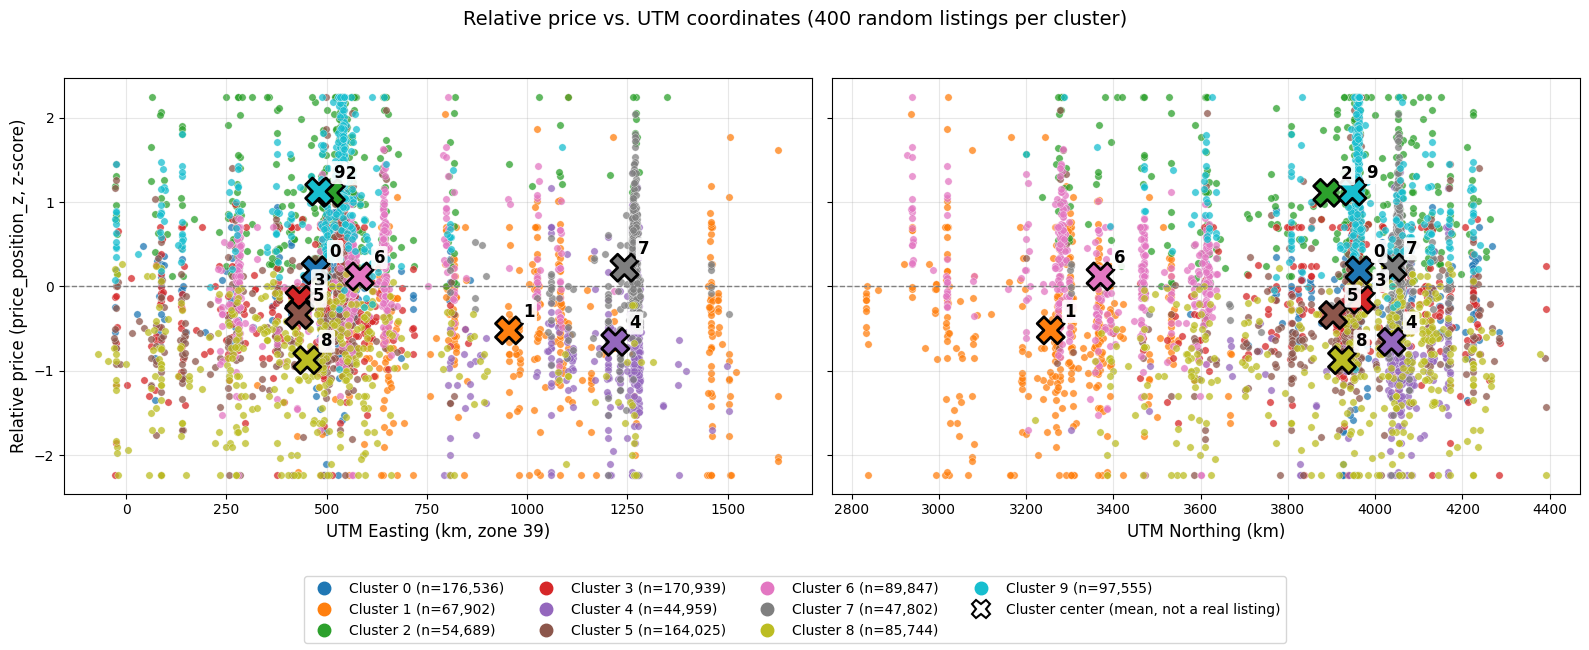

In [31]:
plot_bal = data.groupby('cluster', group_keys=False).sample(n=400, random_state=SEED)

#اسکترپلات قیمت در برابر مختصات UTM
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

for ax, coord, label in zip(axes, ['utm_easting', 'utm_northing'],
                            ['UTM Easting (km, zone 39)', 'UTM Northing (km)']):
    for c in range(K):
        pts = plot_bal[plot_bal['cluster'] == c]
        ax.scatter(pts[coord + '_raw'] / 1000, pts['price_position_z_raw'],
                   s=28, alpha=0.75, color=colors[c], edgecolors='white', linewidths=0.3)
    ax.scatter(centers_raw[coord] / 1000, centers_raw['price_position_z'],
               marker='X', s=380, c=[colors[c] for c in range(K)],
               edgecolors='black', linewidths=2, zorder=5)
    for c in range(K):
        ax.annotate(str(c), (centers_raw.loc[c, coord] / 1000, centers_raw.loc[c, 'price_position_z']),
                    xytext=(10, 10), textcoords='offset points', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.9), zorder=6)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(label, fontsize=12)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Relative price (price_position_z, z-score)', fontsize=12)
fig.suptitle('Relative price vs. UTM coordinates (400 random listings per cluster)', fontsize=14)
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0.14, 1, 0.95])
plt.show()

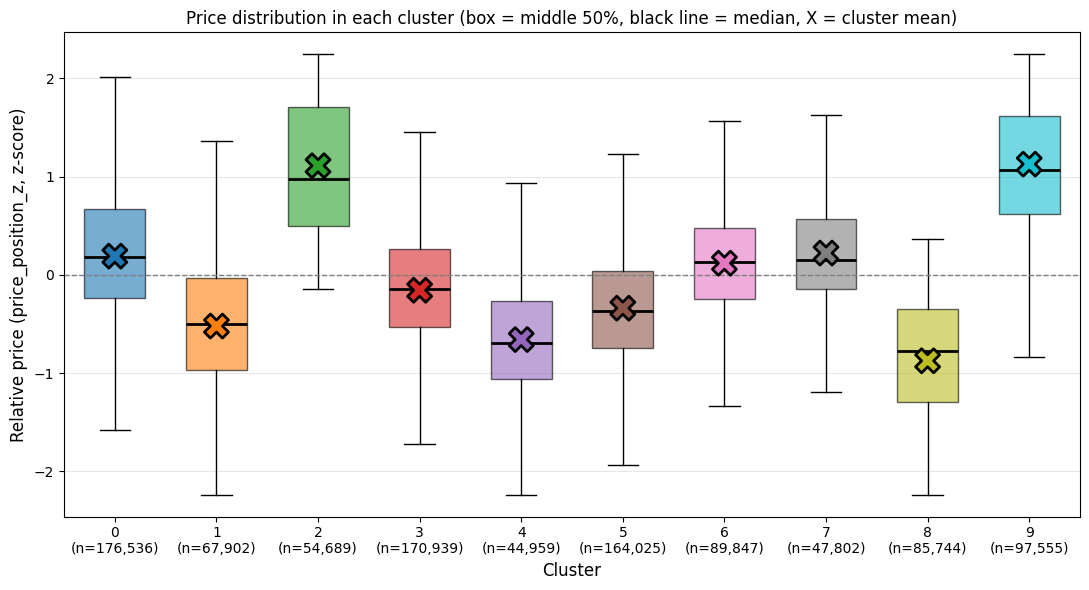

In [32]:

#توزیع قیمت در هر خوشه
fig, ax = plt.subplots(figsize=(11, 6))
groups = [data.loc[data['cluster'] == c, 'price_position_z_raw'].values for c in range(K)]
bp = ax.boxplot(groups, positions=range(K), widths=0.6, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], range(K)):
    patch.set_facecolor(colors[c]); patch.set_alpha(0.6)
ax.scatter(range(K), centers_raw['price_position_z'], marker='X', s=300, c=[colors[c] for c in range(K)],
           edgecolors='black', linewidths=2, zorder=5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(range(K)); ax.set_xticklabels([f'{c}\n(n={sizes[c]:,})' for c in range(K)])
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Relative price (price_position_z, z-score)', fontsize=12)
ax.set_title('Price distribution in each cluster (box = middle 50%, black line = median, X = cluster mean)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

علامت X بزرگ (با شمارهٔ خوشه) مرکز هر خوشه است. مرکز، میانگین ویژگی‌های اعضای خوشه هست و لزوما یه آگهی واقعی نیست. چون خوشه‌بندی روی ۶ ویژگی انجام شده و هر نمودار فقط ۲ تا ۳ تای اونا رو نشون میده، خوشه‌هایی که در نقشه یا نمودار قیمت روی هم افتادن (مثل خوشه‌های ۰، ۳، ۵، ۸ و ۹ در تهران) در بعدهای دیگه، مثل building_size یا amenity_score، از هم جدا میشن. ستون‌های عمودی در اسکترپلات قیمت به این دلیل است که آگهی‌های یک محله مختصات تقریبا مشابهی دارن و خطوط افقی بالا و پایین به‌خاطر کلیپ‌شدن قیمته

</div>